# Введение во временные ряды

Временной ряд — это последовательность наблюдений, упорядоченных по времени (*обычно* с равными интервалами между наблюдениями):

$ts = { y_{1}, y_{2}, …, y_{t} }$

🦋 **Какие примеры временных рядов вы можете привести?**

## Подготовка

In [ ]:
# Работа с данными 
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px

# Тесты на стационарность
from statsmodels.tsa.stattools import adfuller, kpss

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox

## Данные

Рассмотрим датасет с почасовыми значениями влажности в различных городах США. Скачать данные можно [здесь](https://github.com/tirthajyoti/Deep-learning-with-Python/blob/master/Data/historical-hourly-weather-data/humidity.csv).

Данные представлены за период с 2012-10-01 по 2017-11-30.

In [ ]:
# humidity = pd.read_csv('humidity.csv') - можно загружать через csv файл
# или достать файл по ссылке
url = "https://raw.githubusercontent.com/tirthajyoti/Deep-learning-with-Python/80f337d1584fb123f1a8f7dce0ad190f1a08ce14/Data/historical-hourly-weather-data/humidity.csv"

humidity = pd.read_csv(url)
humidity.head()

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
0,2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN
1,2012-10-01 13:00:00,76.0,81.0,88.0,81.0,88.0,82.0,22.0,23.0,50.0,...,71.0,58.0,93.0,68.0,50.0,63.0,22.0,51.0,51.0,50.0
2,2012-10-01 14:00:00,76.0,80.0,87.0,80.0,88.0,81.0,21.0,23.0,49.0,...,70.0,57.0,91.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
3,2012-10-01 15:00:00,76.0,80.0,86.0,80.0,88.0,81.0,21.0,23.0,49.0,...,70.0,57.0,87.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
4,2012-10-01 16:00:00,77.0,80.0,85.0,79.0,88.0,81.0,21.0,23.0,49.0,...,69.0,57.0,84.0,68.0,52.0,62.0,22.0,51.0,51.0,50.0


In [ ]:
humidity.shape

(45253, 37)

Самая простая визуализация (с встроенным matplotlib):

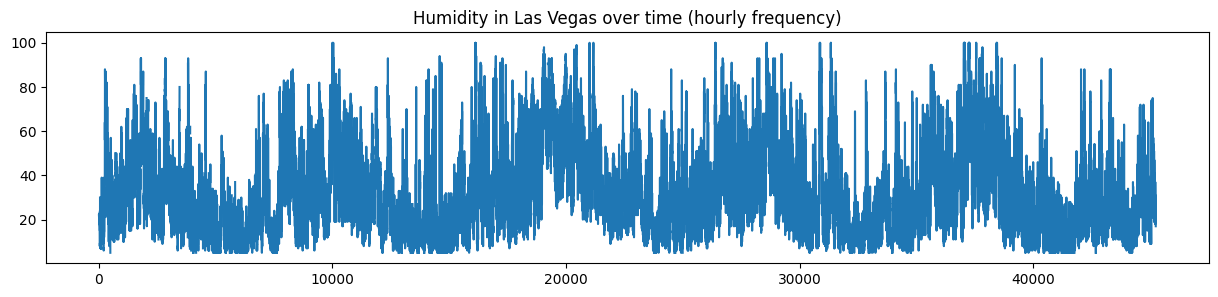

In [ ]:
humidity["Las Vegas"].plot(figsize=(15, 3))
plt.title('Humidity in Las Vegas over time (hourly frequency)')
plt.show()

## Работа с датами

### Timestamp и Period

**Что такое Timestamp и Period, и чем они полезны?**

*Timestamp* используются для представления конкретного момента времени.

*Period* представляют интервал времени. *Period* можно применять, чтобы проверить, попадает ли событие в заданный интервал.

Эти два типа можно преобразовывать друг в друга.

In [ ]:
# Создание Timestamp
timestamp = pd.Timestamp(2017, 1, 1, 4, 20, 42)
timestamp

Timestamp('2017-01-01 04:20:42')

In [ ]:
# Создание Period
period = pd.Period('2017-01-01')
print(period.start_time, '\n', period.end_time)

2017-01-01 00:00:00 
 2017-01-01 23:59:59.999999999


In [ ]:
# Проверяем, попадает ли заданный Timestamp в Period
period.start_time < timestamp < period.end_time

True

In [ ]:
# Преобразуем Timestamp в Period
period_from_tstamp = timestamp.to_period(freq='h')
period_from_tstamp

Period('2017-01-01 04:00', 'h')

In [ ]:
# Преобразуем Period в Timestamp
tstamp_from_period = period.to_timestamp(freq='h', how='start') # start означает начало периода
tstamp_from_period

Timestamp('2017-01-01 00:00:00')

### date_range

**Что такое date_range и чем он полезен?**

*date_range* — это метод, который возвращает DatetimeIndex с фиксированной частотой — "список" дат. Он полезен при создании собственного временного признака для уже имеющихся данных или при организации данных вокруг созданного временного признака.

In [ ]:
# Создаём DatetimeIndex с дневной частотой
dr1 = pd.date_range(start='1/1/18', end='1/9/19', freq='D')
dr1

DatetimeIndex(['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04',
               '2018-01-05', '2018-01-06', '2018-01-07', '2018-01-08',
               '2018-01-09', '2018-01-10',
               ...
               '2018-12-31', '2019-01-01', '2019-01-02', '2019-01-03',
               '2019-01-04', '2019-01-05', '2019-01-06', '2019-01-07',
               '2019-01-08', '2019-01-09'],
              dtype='datetime64[ns]', length=374, freq='D')

In [ ]:
# Создаём DatetimeIndex с месячной частотой
dr2 = pd.date_range(start='1/1/18', end='1/1/19', freq='MS') # MS — начало месяца, ME — конец
dr2

DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01',
               '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01',
               '2019-01-01'],
              dtype='datetime64[ns]', freq='MS')

In [ ]:
# Создаём DatetimeIndex без указания даты начала, задавая количество периодов
dr3 = pd.date_range(end='1/4/2014', periods=8)
dr3

DatetimeIndex(['2013-12-28', '2013-12-29', '2013-12-30', '2013-12-31',
               '2014-01-01', '2014-01-02', '2014-01-03', '2014-01-04'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
# Создаём DatetimeIndex, задавая дату начала, дату окончания и количество периодов
dr4 = pd.date_range(start='2013-04-24', end='2014-11-27', periods=3)
dr4

DatetimeIndex(['2013-04-24', '2014-02-09', '2014-11-27'], dtype='datetime64[ns]', freq=None)

### to_datetime

*pandas.to_datetime()* используется для преобразования аргументов в объект Timestamp.


In [ ]:
d = pd.to_datetime('01-01-2017 4:20:42.42', format='%d-%m-%Y %H:%M:%S.%f') # format обычно не требуется, но иногда бывает полезен
d

Timestamp('2017-01-01 04:20:42.420000')

Мы также можем преобразовывать DataFrame с помощью *pd.to_datetime*.

In [ ]:
# Создадим df
df = pd.DataFrame({'year': [2015, 2016], 'month': [2, 3], 'day': [4, 5]})
df

,year,month,day
0,2015,2,4
1,2016,3,5


Примечание: `Timestamp` — скалярный тип pandas для представления момента времени, совместимый с `datetime` и `numpy.datetime64`.

In [ ]:
# Преобразуем в datetime
df = pd.to_datetime(df)
df

,0
0,2015-02-04
1,2016-03-05


## Фильтрация по дате

Отфильтруем наш датасет с влажностью за 2016 год.

In [ ]:
humidity.head()

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
0,2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN
1,2012-10-01 13:00:00,76.0,81.0,88.0,81.0,88.0,82.0,22.0,23.0,50.0,...,71.0,58.0,93.0,68.0,50.0,63.0,22.0,51.0,51.0,50.0
2,2012-10-01 14:00:00,76.0,80.0,87.0,80.0,88.0,81.0,21.0,23.0,49.0,...,70.0,57.0,91.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
3,2012-10-01 15:00:00,76.0,80.0,86.0,80.0,88.0,81.0,21.0,23.0,49.0,...,70.0,57.0,87.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
4,2012-10-01 16:00:00,77.0,80.0,85.0,79.0,88.0,81.0,21.0,23.0,49.0,...,69.0,57.0,84.0,68.0,52.0,62.0,22.0,51.0,51.0,50.0


In [ ]:
humidity.dtypes[:3]

,0
datetime,object
Vancouver,float64
Portland,float64


🦋 **Как отфильтровать 2016 год?**


Чтобы отфильтровать 2016 год, нужно привести столбец *datetime* к типу *datetime64* с помощью *to_datetime*.

In [ ]:
humidity['datetime'] = pd.to_datetime(humidity['datetime'])
humidity.dtypes[:3]

,0
datetime,datetime64[ns]
Vancouver,float64
Portland,float64


Теперь можно отфильтровать с помощью *dt.year*.

In [ ]:
humidity[humidity['datetime'].dt.year == 2016]

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
28476,2016-01-01 00:00:00,74.0,47.0,69.0,70.0,17.0,28.0,22.0,21.0,39.0,...,82.0,65.0,74.0,61.0,100.0,93.0,100.0,100.0,100.0,93.0
28477,2016-01-01 01:00:00,78.0,47.0,74.0,86.0,22.0,38.0,22.0,26.0,41.0,...,82.0,73.0,74.0,59.0,100.0,88.0,100.0,100.0,100.0,91.0
28478,2016-01-01 02:00:00,100.0,59.0,85.0,92.0,33.0,59.0,34.0,42.0,47.0,...,82.0,100.0,74.0,79.0,100.0,62.0,100.0,100.0,100.0,62.0
28479,2016-01-01 03:00:00,97.0,55.0,80.0,92.0,21.0,53.0,24.0,30.0,47.0,...,82.0,89.0,74.0,69.0,100.0,63.0,96.0,97.0,97.0,62.0
28480,2016-01-01 04:00:00,86.0,55.0,77.0,72.0,27.0,61.0,26.0,29.0,57.0,...,81.0,56.0,79.0,64.0,100.0,71.0,67.0,81.0,81.0,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37255,2016-12-31 19:00:00,100.0,80.0,66.0,86.0,82.0,63.0,81.0,82.0,75.0,...,35.0,33.0,85.0,43.0,84.0,87.0,40.0,93.0,93.0,87.0
37256,2016-12-31 20:00:00,93.0,80.0,62.0,100.0,76.0,67.0,81.0,77.0,70.0,...,48.0,28.0,85.0,51.0,88.0,87.0,43.0,93.0,93.0,87.0
37257,2016-12-31 21:00:00,100.0,80.0,62.0,93.0,87.0,63.0,81.0,72.0,81.0,...,48.0,33.0,78.0,51.0,88.0,81.0,43.0,93.0,93.0,81.0
37258,2016-12-31 22:00:00,100.0,80.0,58.0,93.0,93.0,72.0,81.0,72.0,75.0,...,48.0,41.0,92.0,65.0,88.0,81.0,50.0,100.0,100.0,81.0


Другой способ — фильтрация с помощью *np.datetime64*.

In [ ]:
humidity[(humidity['datetime'] >= np.datetime64('2016-01-01'))&(humidity['datetime'] <= np.datetime64('2016-12-31'))]

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
28476,2016-01-01 00:00:00,74.0,47.0,69.0,70.0,17.0,28.0,22.0,21.0,39.0,...,82.0,65.0,74.0,61.0,100.0,93.0,100.0,100.0,100.0,93.0
28477,2016-01-01 01:00:00,78.0,47.0,74.0,86.0,22.0,38.0,22.0,26.0,41.0,...,82.0,73.0,74.0,59.0,100.0,88.0,100.0,100.0,100.0,91.0
28478,2016-01-01 02:00:00,100.0,59.0,85.0,92.0,33.0,59.0,34.0,42.0,47.0,...,82.0,100.0,74.0,79.0,100.0,62.0,100.0,100.0,100.0,62.0
28479,2016-01-01 03:00:00,97.0,55.0,80.0,92.0,21.0,53.0,24.0,30.0,47.0,...,82.0,89.0,74.0,69.0,100.0,63.0,96.0,97.0,97.0,62.0
28480,2016-01-01 04:00:00,86.0,55.0,77.0,72.0,27.0,61.0,26.0,29.0,57.0,...,81.0,56.0,79.0,64.0,100.0,71.0,67.0,81.0,81.0,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37232,2016-12-30 20:00:00,86.0,81.0,24.0,75.0,82.0,76.0,61.0,42.0,52.0,...,48.0,51.0,67.0,39.0,77.0,76.0,58.0,100.0,100.0,76.0
37233,2016-12-30 21:00:00,86.0,70.0,23.0,70.0,76.0,71.0,57.0,40.0,45.0,...,47.0,44.0,62.0,42.0,77.0,76.0,58.0,100.0,100.0,76.0
37234,2016-12-30 22:00:00,80.0,70.0,21.0,70.0,67.0,62.0,53.0,42.0,48.0,...,47.0,86.0,67.0,41.0,77.0,66.0,66.0,100.0,100.0,66.0
37235,2016-12-30 23:00:00,15.0,70.0,22.0,70.0,72.0,67.0,61.0,40.0,45.0,...,40.0,64.0,62.0,38.0,76.0,66.0,100.0,100.0,100.0,66.0


🦋 **В чем ошибка в коде выше?**


In [ ]:
humidity[(humidity['datetime'] >= np.datetime64('2016-01-01'))&(humidity['datetime'] < np.datetime64('2017-01-01'))]

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
28476,2016-01-01 00:00:00,74.0,47.0,69.0,70.0,17.0,28.0,22.0,21.0,39.0,...,82.0,65.0,74.0,61.0,100.0,93.0,100.0,100.0,100.0,93.0
28477,2016-01-01 01:00:00,78.0,47.0,74.0,86.0,22.0,38.0,22.0,26.0,41.0,...,82.0,73.0,74.0,59.0,100.0,88.0,100.0,100.0,100.0,91.0
28478,2016-01-01 02:00:00,100.0,59.0,85.0,92.0,33.0,59.0,34.0,42.0,47.0,...,82.0,100.0,74.0,79.0,100.0,62.0,100.0,100.0,100.0,62.0
28479,2016-01-01 03:00:00,97.0,55.0,80.0,92.0,21.0,53.0,24.0,30.0,47.0,...,82.0,89.0,74.0,69.0,100.0,63.0,96.0,97.0,97.0,62.0
28480,2016-01-01 04:00:00,86.0,55.0,77.0,72.0,27.0,61.0,26.0,29.0,57.0,...,81.0,56.0,79.0,64.0,100.0,71.0,67.0,81.0,81.0,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37255,2016-12-31 19:00:00,100.0,80.0,66.0,86.0,82.0,63.0,81.0,82.0,75.0,...,35.0,33.0,85.0,43.0,84.0,87.0,40.0,93.0,93.0,87.0
37256,2016-12-31 20:00:00,93.0,80.0,62.0,100.0,76.0,67.0,81.0,77.0,70.0,...,48.0,28.0,85.0,51.0,88.0,87.0,43.0,93.0,93.0,87.0
37257,2016-12-31 21:00:00,100.0,80.0,62.0,93.0,87.0,63.0,81.0,72.0,81.0,...,48.0,33.0,78.0,51.0,88.0,81.0,43.0,93.0,93.0,81.0
37258,2016-12-31 22:00:00,100.0,80.0,58.0,93.0,93.0,72.0,81.0,72.0,75.0,...,48.0,41.0,92.0,65.0,88.0,81.0,50.0,100.0,100.0,81.0


Считаем данные заново для более удобной фильтрации в будущем: используем параметр *parse_dates*.

In [ ]:
humidity = pd.read_csv(url, index_col='datetime', parse_dates=['datetime'])
humidity.head()

,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,Denver,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
datetime,,,,,,,,,,,,,,,,,,,,,
2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN
2012-10-01 13:00:00,76.0,81.0,88.0,81.0,88.0,82.0,22.0,23.0,50.0,62.0,...,71.0,58.0,93.0,68.0,50.0,63.0,22.0,51.0,51.0,50.0
2012-10-01 14:00:00,76.0,80.0,87.0,80.0,88.0,81.0,21.0,23.0,49.0,62.0,...,70.0,57.0,91.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
2012-10-01 15:00:00,76.0,80.0,86.0,80.0,88.0,81.0,21.0,23.0,49.0,62.0,...,70.0,57.0,87.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
2012-10-01 16:00:00,77.0,80.0,85.0,79.0,88.0,81.0,21.0,23.0,49.0,62.0,...,69.0,57.0,84.0,68.0,52.0,62.0,22.0,51.0,51.0,50.0


In [ ]:
humidity[humidity.index.year == 2016]

,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,Denver,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,74.0,47.0,69.0,70.0,17.0,28.0,22.0,21.0,39.0,59.0,...,82.0,65.0,74.0,61.0,100.0,93.0,100.0,100.0,100.0,93.0
2016-01-01 01:00:00,78.0,47.0,74.0,86.0,22.0,38.0,22.0,26.0,41.0,67.0,...,82.0,73.0,74.0,59.0,100.0,88.0,100.0,100.0,100.0,91.0
2016-01-01 02:00:00,100.0,59.0,85.0,92.0,33.0,59.0,34.0,42.0,47.0,61.0,...,82.0,100.0,74.0,79.0,100.0,62.0,100.0,100.0,100.0,62.0
2016-01-01 03:00:00,97.0,55.0,80.0,92.0,21.0,53.0,24.0,30.0,47.0,67.0,...,82.0,89.0,74.0,69.0,100.0,63.0,96.0,97.0,97.0,62.0
2016-01-01 04:00:00,86.0,55.0,77.0,72.0,27.0,61.0,26.0,29.0,57.0,69.0,...,81.0,56.0,79.0,64.0,100.0,71.0,67.0,81.0,81.0,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:00:00,100.0,80.0,66.0,86.0,82.0,63.0,81.0,82.0,75.0,55.0,...,35.0,33.0,85.0,43.0,84.0,87.0,40.0,93.0,93.0,87.0
2016-12-31 20:00:00,93.0,80.0,62.0,100.0,76.0,67.0,81.0,77.0,70.0,51.0,...,48.0,28.0,85.0,51.0,88.0,87.0,43.0,93.0,93.0,87.0
2016-12-31 21:00:00,100.0,80.0,62.0,93.0,87.0,63.0,81.0,72.0,81.0,47.0,...,48.0,33.0,78.0,51.0,88.0,81.0,43.0,93.0,93.0,81.0


In [ ]:
humidity.loc['2016-01-01':'2016-12-31']

,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,Denver,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,74.0,47.0,69.0,70.0,17.0,28.0,22.0,21.0,39.0,59.0,...,82.0,65.0,74.0,61.0,100.0,93.0,100.0,100.0,100.0,93.0
2016-01-01 01:00:00,78.0,47.0,74.0,86.0,22.0,38.0,22.0,26.0,41.0,67.0,...,82.0,73.0,74.0,59.0,100.0,88.0,100.0,100.0,100.0,91.0
2016-01-01 02:00:00,100.0,59.0,85.0,92.0,33.0,59.0,34.0,42.0,47.0,61.0,...,82.0,100.0,74.0,79.0,100.0,62.0,100.0,100.0,100.0,62.0
2016-01-01 03:00:00,97.0,55.0,80.0,92.0,21.0,53.0,24.0,30.0,47.0,67.0,...,82.0,89.0,74.0,69.0,100.0,63.0,96.0,97.0,97.0,62.0
2016-01-01 04:00:00,86.0,55.0,77.0,72.0,27.0,61.0,26.0,29.0,57.0,69.0,...,81.0,56.0,79.0,64.0,100.0,71.0,67.0,81.0,81.0,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:00:00,100.0,80.0,66.0,86.0,82.0,63.0,81.0,82.0,75.0,55.0,...,35.0,33.0,85.0,43.0,84.0,87.0,40.0,93.0,93.0,87.0
2016-12-31 20:00:00,93.0,80.0,62.0,100.0,76.0,67.0,81.0,77.0,70.0,51.0,...,48.0,28.0,85.0,51.0,88.0,87.0,43.0,93.0,93.0,87.0
2016-12-31 21:00:00,100.0,80.0,62.0,93.0,87.0,63.0,81.0,72.0,81.0,47.0,...,48.0,33.0,78.0,51.0,88.0,81.0,43.0,93.0,93.0,81.0


# Визуализация с помощью matplotlib

[Matplotlib](https://matplotlib.org/) — это библиотека Python для построения визуализаций на данных. Она предоставляет широкий набор инструментов для создания линейных графиков, гистограмм, диаграмм рассеяния и других типов графиков. Широко используется в задачах анализа данных и машинного обучения.

## Предобработка

In [ ]:
humidity.head()

,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,Denver,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
datetime,,,,,,,,,,,,,,,,,,,,,
2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN
2012-10-01 13:00:00,76.0,81.0,88.0,81.0,88.0,82.0,22.0,23.0,50.0,62.0,...,71.0,58.0,93.0,68.0,50.0,63.0,22.0,51.0,51.0,50.0
2012-10-01 14:00:00,76.0,80.0,87.0,80.0,88.0,81.0,21.0,23.0,49.0,62.0,...,70.0,57.0,91.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
2012-10-01 15:00:00,76.0,80.0,86.0,80.0,88.0,81.0,21.0,23.0,49.0,62.0,...,70.0,57.0,87.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
2012-10-01 16:00:00,77.0,80.0,85.0,79.0,88.0,81.0,21.0,23.0,49.0,62.0,...,69.0,57.0,84.0,68.0,52.0,62.0,22.0,51.0,51.0,50.0


In [ ]:
humidity.isna().sum()

,0
Vancouver,1826
Portland,449
San Francisco,942
Seattle,289
Los Angeles,152
San Diego,344
Las Vegas,842
Phoenix,1308
Albuquerque,710
Denver,1808


Заполним пропуски.

In [ ]:
humidity = humidity.iloc[1:] # удаляем первую пустую строку
humidity = humidity.ffill() # заполняем пропуски последним известным значением
humidity.head()

,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,Denver,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
datetime,,,,,,,,,,,,,,,,,,,,,
2012-10-01 13:00:00,76.0,81.0,88.0,81.0,88.0,82.0,22.0,23.0,50.0,62.0,...,71.0,58.0,93.0,68.0,50.0,63.0,22.0,51.0,51.0,50.0
2012-10-01 14:00:00,76.0,80.0,87.0,80.0,88.0,81.0,21.0,23.0,49.0,62.0,...,70.0,57.0,91.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
2012-10-01 15:00:00,76.0,80.0,86.0,80.0,88.0,81.0,21.0,23.0,49.0,62.0,...,70.0,57.0,87.0,68.0,51.0,62.0,22.0,51.0,51.0,50.0
2012-10-01 16:00:00,77.0,80.0,85.0,79.0,88.0,81.0,21.0,23.0,49.0,62.0,...,69.0,57.0,84.0,68.0,52.0,62.0,22.0,51.0,51.0,50.0
2012-10-01 17:00:00,78.0,79.0,84.0,79.0,88.0,80.0,21.0,24.0,49.0,63.0,...,69.0,57.0,80.0,68.0,54.0,62.0,23.0,51.0,51.0,50.0


In [ ]:
# Проверим, остались ли пропуски

humidity.isna().sum().sum()

np.int64(0)

Давайте подробнее изучим влажность в Лас-Вегасе.

In [ ]:
humidity_lv = humidity["Las Vegas"]
humidity_lv.head()

,Las Vegas
datetime,
2012-10-01 13:00:00,22.0
2012-10-01 14:00:00,21.0
2012-10-01 15:00:00,21.0
2012-10-01 16:00:00,21.0
2012-10-01 17:00:00,21.0


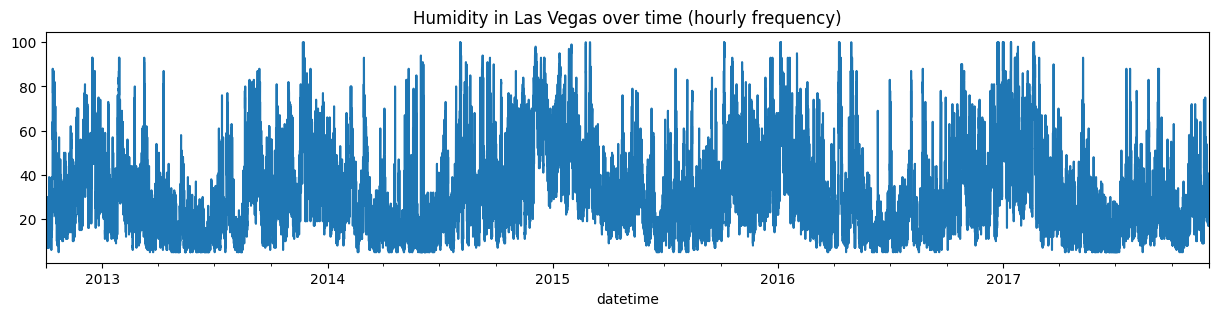

In [ ]:
humidity_lv.plot(figsize=(15, 3))
plt.title('Humidity in Las Vegas over time (hourly frequency)')
plt.show()

## Добавление вертикальных и горизонтальных линий

In [ ]:
# Вспомним, как выглядят данные
humidity_lv

,Las Vegas
datetime,
2012-10-01 13:00:00,22.0
2012-10-01 14:00:00,21.0
2012-10-01 15:00:00,21.0
2012-10-01 16:00:00,21.0
2012-10-01 17:00:00,21.0
...,...
2017-11-29 20:00:00,18.0
2017-11-29 21:00:00,18.0
2017-11-29 22:00:00,17.0


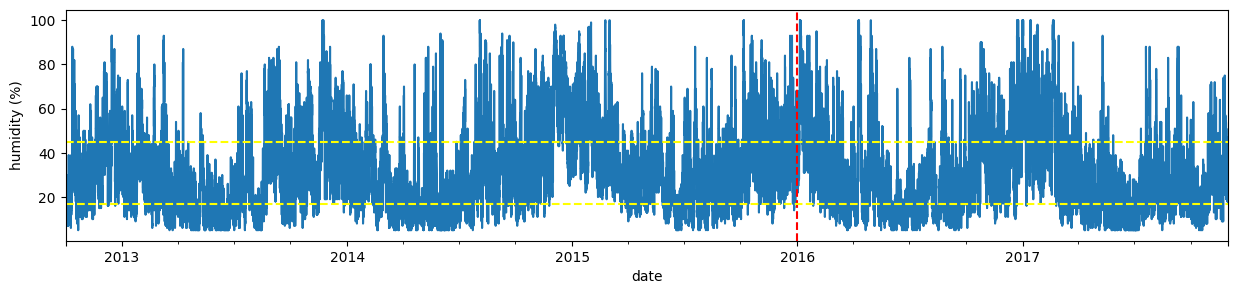

In [ ]:
ax = humidity_lv.plot(figsize=(15, 3))
ax.set_xlabel('date')
ax.set_ylabel('humidity (%)')
ax.axvline('2016-01-01', color='red', linestyle='--')
ax.axhline(17, color='yellow', linestyle='--')
ax.axhline(45, color='yellow', linestyle='--')

## Resampling (изменение гранулярности)

**Upsampling** — временной ряд переводится с более низкой частоты на более высокую (например, с месячной на дневную). Это подразумевает заполнения или интерполяции пропусков.

**Downsampling** — временной ряд переводится с более высокой частоты на более низкую (например, с дневной на месячную). Это подразумевает агрегацию существующих данных.

Метод *asfreq* — просто изменяет частоту, пропуская или добавляя значения (добавление задаётся параметром *method*).

In [ ]:
humidity_lv.asfreq('D', method='bfill').head() # bfill — заполняет следующим доступным значением

,Las Vegas
datetime,
2012-10-01 13:00:00,22.0
2012-10-02 13:00:00,18.0
2012-10-03 13:00:00,21.0
2012-10-04 13:00:00,28.0
2012-10-05 13:00:00,22.0


*resample* — изменяет частоту с помощью агрегаций.

Давайте продолжим работать с данными в дневной гранулярности.

In [ ]:
humidity_lv = humidity_lv.resample('D').mean()

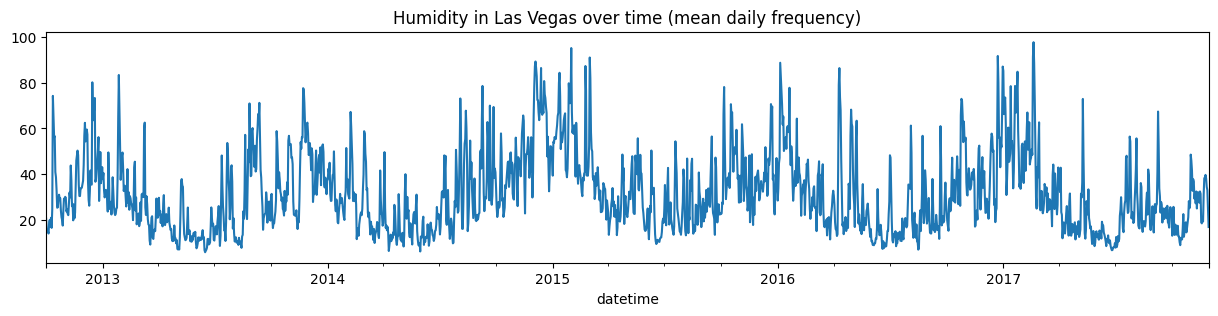

In [ ]:
humidity_lv.plot(figsize=(15, 3))
plt.title('Humidity in Las Vegas over time (mean daily frequency)')
plt.show()

## Оконные функции

Оконные функции часто используются при анализе вр. рядов. Сглаживание временного ряда применяют, чтобы уменьшить краткосрочные колебания и выявить более устойчивые тренды.

Реальные данные часто содержат шум — случайные колебания, которые скрывают основные закономерности. Методы сглаживания, например скользящее среднее, снижают шум, делают данные более интерпретируемыми и подчёркивают сезонные и долгосрочные изменения.

Картинки иллюстрируют часто используемые способы сглаживания: *expanding window average* и *sliding window average*.

*(!) Иллюстрация показывает окна для cross-validation, но логика сглаживания такая же.*

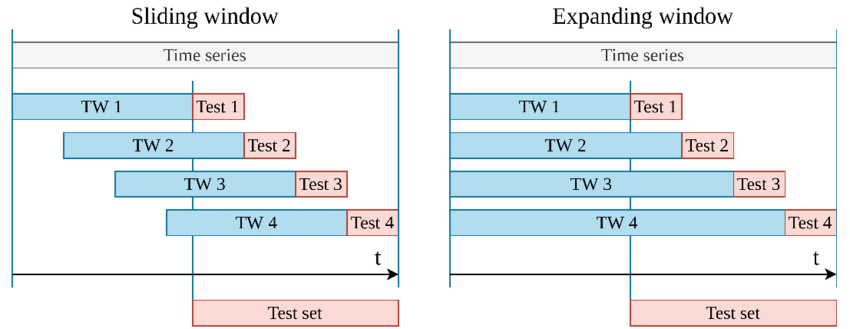

*Expanding window average* (расширяющееся окно с усреднением) полезно для отслеживания накопительных трендов во времени. В отличие от окна фиксированной ширины оно постоянно обновляется по мере поступления новых данных:

${ExpandingMean}_t = \frac{1}{t} \sum_{i=1}^{t} y_{i}$.

In [ ]:
humidity_lv_expanding = humidity_lv.expanding().mean()

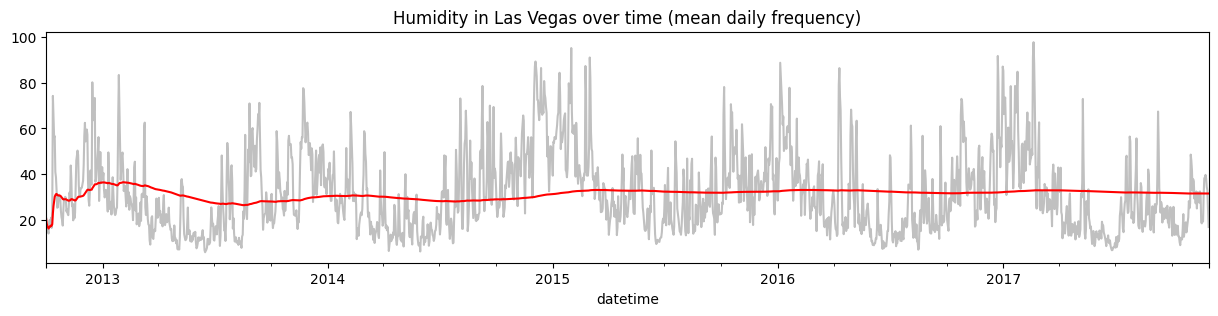

In [ ]:
humidity_lv.plot(color='silver',figsize=(15, 3))
humidity_lv_expanding.plot(color='red')
plt.title('Humidity in Las Vegas over time (mean daily frequency)')
plt.show()

Видно, что изначальные данные очень волатильны. *Sliding moving average* (скользящее окно с усреднением) усредняет значения в окне, уменьшая колебания:

${SMA}_t = \frac{1}{k} \sum_{i=t-k+1}^{t} y_{i}$, $k$ — размер окна.

Сгладим наш датафрейм скользящим окном с шириной в 7 дней.

In [ ]:
humidity_lv_smoothed = humidity_lv.rolling(window=7).mean()

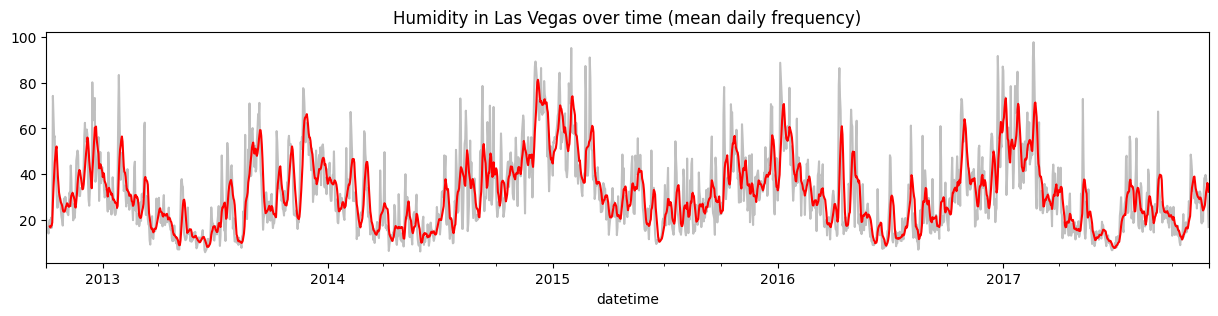

In [ ]:
humidity_lv.plot(color='silver',figsize=(15, 3))
humidity_lv_smoothed.plot(color='red')
plt.title('Humidity in Las Vegas over time (mean daily frequency)')
plt.show()

Колебания всё ещё заметны. Сгладим данные с шириной окна 4 недели.

In [ ]:
humidity_lv_smoothed = humidity_lv.rolling(window=28).mean()

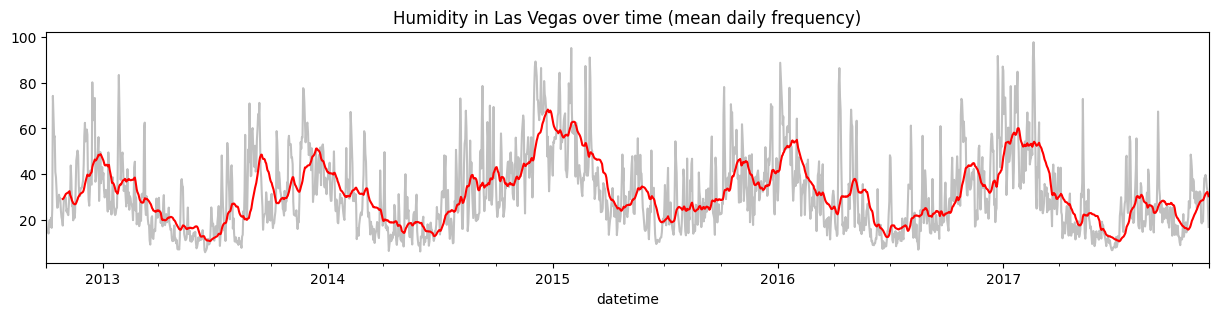

In [ ]:
humidity_lv.plot(color='silver',figsize=(15, 3))
humidity_lv_smoothed.plot(color='red')
plt.title('Humidity in Las Vegas over time (mean daily frequency)')
plt.show()

🦋 **Предположите, какой размер окна может дать более гладкий временной ряд.**

In [ ]:
humidity_lv_smoothed = humidity_lv.rolling(window=90).mean()

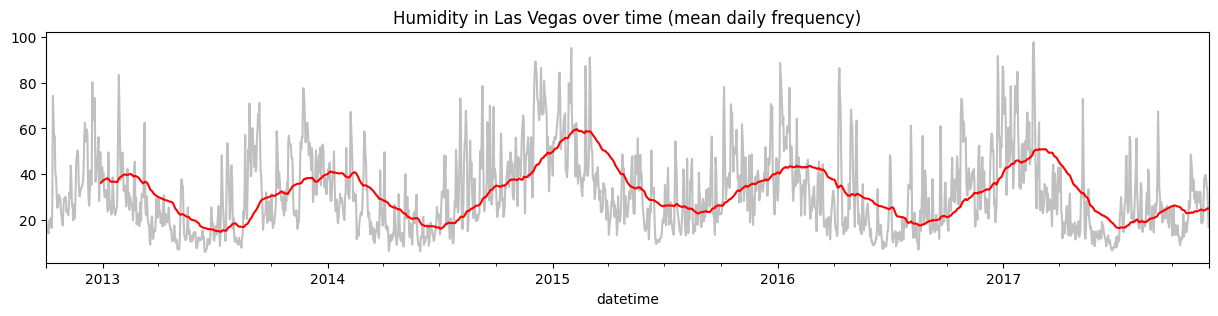

In [ ]:
humidity_lv.plot(color='silver',figsize=(15, 3))
humidity_lv_smoothed.plot(color='red')
plt.title('Humidity in Las Vegas over time (mean daily frequency)')
plt.show()

## Паттерны временных рядов

Изучим паттерны, которые может содержать временной ряд.

Попробуем найти годовую сезонность.

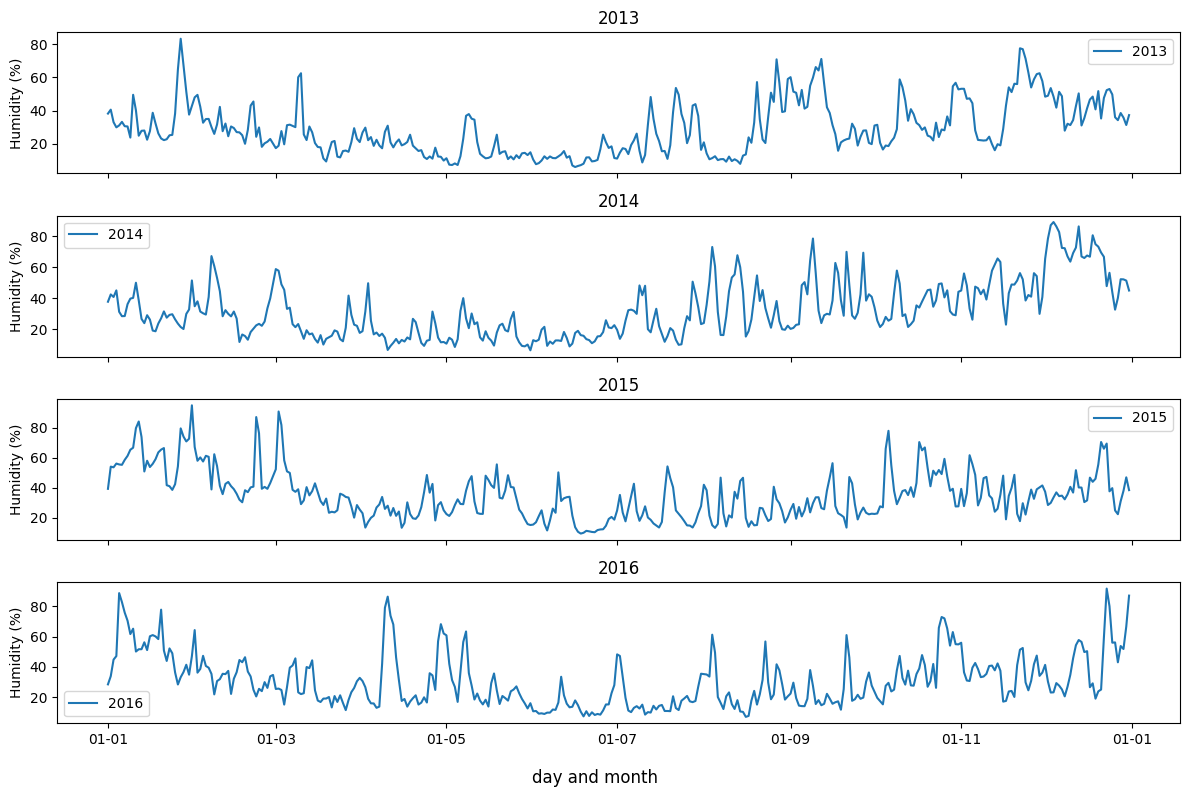

In [ ]:
# Оставляем только полные календарные годы.
complete_years = [
    year for year, values in humidity_lv.groupby(humidity_lv.index.year)
    if len(values) == pd.Timestamp(year=year, month=12, day=31).dayofyear
]

fig, axes = plt.subplots(
    len(complete_years), 1, figsize=(12, 8), sharex=True
)

for i, year in enumerate(complete_years):
    yearly_data = humidity_lv[humidity_lv.index.year == year]
    # 2000 — високосный год: 29 февраля корректно попадает на общую ось.
    plot_date = pd.to_datetime(yearly_data.index.strftime('2000-%m-%d'))
    axes[i].plot(plot_date, yearly_data, label=f'{year}')
    axes[i].set_ylabel('Humidity (%)')
    axes[i].legend()
    axes[i].set_title(f'{year}')

axes[-1].xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%d-%m')
)
fig.supxlabel('day and month')
plt.tight_layout()
plt.show()

🦋 **Какие сезонные паттерны вы замечаете?**

Чтобы нагляднее увидеть годовые зависимости, построим все годы на одном графике.

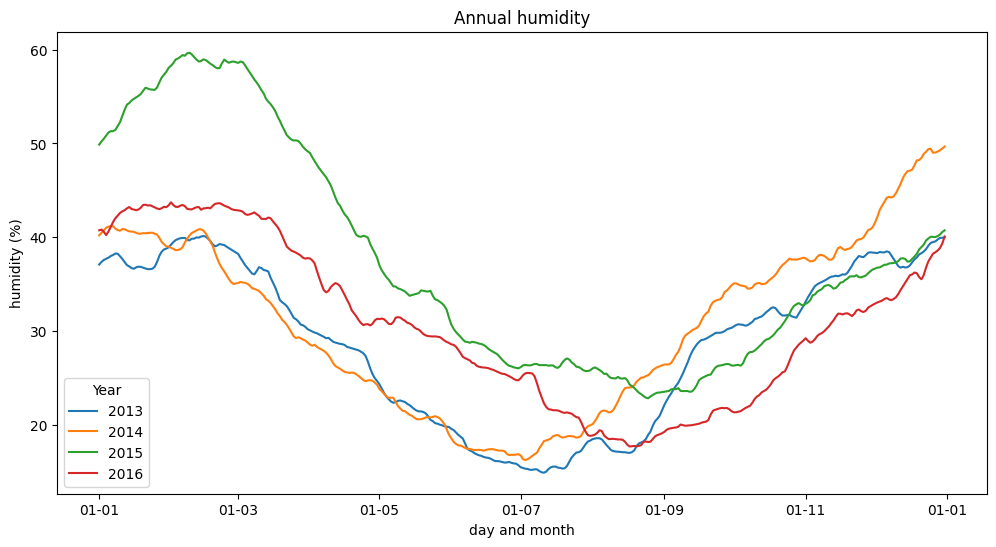

In [ ]:
complete_years = [
    year for year, values in humidity_lv.groupby(humidity_lv.index.year)
    if len(values) == pd.Timestamp(year=year, month=12, day=31).dayofyear
]

plt.figure(figsize=(12, 6))

for year in complete_years:
    yearly_data = humidity_lv_smoothed[
        humidity_lv_smoothed.index.year == year
    ]
    plot_date = pd.to_datetime(yearly_data.index.strftime('2000-%m-%d'))
    plt.plot(plot_date, yearly_data, label=f'{year}')

plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%d-%m')
)
plt.xlabel('day and month')
plt.ylabel('humidity (%)')
plt.title('Annual humidity')
plt.legend(title='Year')
plt.show()

🦋 **Какие сезонные паттерны вы видите сейчас?**

# Визуализация с помощью plotly.express

[Plotly Express](https://plotly.com/python/plotly-express/) - это высокоуровневая библиотека Python для создания интерактивных визуализаций. Plotly Express широко используется из-за простоты использования, быстрой генерации красивых интерактивных графиков и интеграции с другими инструментами анализа данных. Он идеально подходит для визуализации сложных наборов данных и изучения тенденций интуитивно понятным и интерактивным способом, что делает его отличным выбором для обработки данных и бизнес-аналитики.

In [ ]:
fig = px.line(humidity_lv, x=humidity_lv.index, y=humidity_lv,
              title="Humidity in Las Vegas over time (avg daily frequency)")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

In [ ]:
fig = px.line(title="Humidity in Las Vegas over time (avg daily frequency)")
fig.add_scatter(x=humidity_lv.index, y=humidity_lv, mode='lines', name='Original Humidity', line=dict(color='silver'))
fig.add_scatter(x=humidity_lv_smoothed.index, y=humidity_lv_smoothed, mode='lines', name='SMA', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

In [ ]:
complete_years = [
    year for year, values in humidity_lv.groupby(humidity_lv.index.year)
    if len(values) == pd.Timestamp(year=year, month=12, day=31).dayofyear
]

humidity_lv_smoothed_plot = humidity_lv_smoothed[
    humidity_lv_smoothed.index.year.isin(complete_years)
].reset_index()
humidity_lv_smoothed_plot['year'] = (
    humidity_lv_smoothed_plot['datetime'].dt.year
)
humidity_lv_smoothed_plot['plot_date'] = pd.to_datetime(
    humidity_lv_smoothed_plot['datetime'].dt.strftime('2000-%m-%d')
)

fig = px.line(
    humidity_lv_smoothed_plot,
    x='plot_date',
    y='Las Vegas',
    color='year',
    line_group='year',
    title='Annual humidity',
    labels={'plot_date': 'day and month', 'Las Vegas': 'humidity (%)'}
)

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(tickformat='%d-%m')
fig.show()

## MoM & YoY growth rates (темпы роста)

**Year-over-year (YoY)** and **month-over-month (MoM)** темпы роста являются общепринятыми показателями в финансовой отчетности, поскольку они помогают отслеживать динамику и тренды бизнес-показателей. MoM аналищ позволяет нам увидеть краткосрочные изменения, выявить сезонные колебания и оценить реакцию на недавние бизнес-инициативы. В свою очередь, YoY анализ позволяет провести сравнение с аналогичными периодами предыдущего года, что важно для оценки долгосрочных тенденций. Вместе данные MoM и YoY дают более полное представление о финансовом состоянии компании, помогая принимать обоснованные управленческие решения и вносить стратегические коррективы.

$\text{MoM} = \frac{\text{Значения текущего месяца} - \text{Значения пред. месяца}}{\text{Значения пред. месяца}} \times 100\%$,

что тоже самое, что и:

$\text{MoM} = \left( \frac{\text{Значения текущего месяца}}{\text{Значения пред. месяца}} - 1 \right) \times 100\%
$

🦋 **Преобразуйте "humidity_lv" к месячной гранулярности.**

In [ ]:
humidity_monthly = humidity_lv.resample('MS').mean()

In [ ]:
fig = px.line(humidity_monthly, x=humidity_monthly.index, y=humidity_monthly,
              title="Humidity in Las Vegas over time (monthly frequency)")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

In [ ]:
humidity_monthly = pd.DataFrame(humidity_monthly)

На месячной гранулярности MoM могут быть посчитаны через метод *.pct_change()*.

In [ ]:
humidity_monthly['MoM'] = humidity_monthly['Las Vegas'].pct_change() * 100

In [ ]:
humidity_monthly # вы можете рассчитать MoMs вручную - чтобы проверить, все ли правильно :)

,Las Vegas,MoM
datetime,,
2012-10-01,29.075880,NaN
2012-11-01,32.211111,10.782929
2012-12-01,47.879032,48.641356
2013-01-01,35.903226,-25.012633
2013-02-01,31.050595,-13.515862
...,...,...
2017-07-01,24.049731,101.229593
2017-08-01,25.845430,7.466607
2017-09-01,26.838889,3.843847


Подготовим более удобную таблицу. Такой формат обычно используется для представления финансовых данных о темпах роста.

In [ ]:
humidity_monthly.index = pd.to_datetime(humidity_monthly.index)
humidity_monthly['year'] = humidity_monthly.index.year
humidity_monthly['month'] = humidity_monthly.index.month

# Разверните данные, чтобы получить годы в строках и месяцы в столбцах.
pivot_table = humidity_monthly.pivot_table(index='year', columns='month', values='MoM')


In [ ]:
pivot_table

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.782929,48.641356
2013,-25.012633,-13.515862,-23.611493,-19.602954,-14.164885,-26.942027,116.140272,-0.514821,49.984841,-14.555859,34.981985,-5.238284
2014,-25.325255,-1.426558,-22.621490,-27.958235,4.459866,-15.569856,69.766766,41.443920,12.361539,-14.283662,31.297545,42.558398
2015,-7.627015,-21.059868,-20.597527,-32.623543,27.068633,-41.177268,29.737314,2.523540,12.048389,53.852279,-17.936088,11.813777
2016,29.913736,-33.764324,-27.307405,34.322919,-21.279898,-49.522950,33.653330,38.233326,-7.860972,70.051003,-8.912424,23.654030
2017,25.977628,-3.236164,-45.124857,-29.281147,2.192775,-43.939012,101.229593,7.466607,3.843847,-36.929508,86.490657,NaN



🦋 **Расчитайте YoY за все года для Нью-Йорка аналогичным способом.**

In [ ]:
humidity_ny = humidity["New York"]
humidity_ny.head()

,New York
datetime,
2012-10-01 13:00:00,58.0
2012-10-01 14:00:00,57.0
2012-10-01 15:00:00,57.0
2012-10-01 16:00:00,57.0
2012-10-01 17:00:00,57.0


🦋 **Будет ли разница между ресемплингами: H -> D -> Y vs H -> Y?**

In [ ]:
humidity_ny.resample('D').mean().resample('YS').mean()

,New York
datetime,
2012-01-01,67.038291
2013-01-01,67.314726
2014-01-01,63.734132
2015-01-01,70.579452
2016-01-01,65.331853
2017-01-01,64.496382


In [ ]:
humidity_ny.resample('YS').mean()

,New York
datetime,
2012-01-01,67.102050
2013-01-01,67.314726
2014-01-01,63.734132
2015-01-01,70.579452
2016-01-01,65.331853
2017-01-01,64.515076


In [ ]:
humidity_ny = humidity_ny.resample('D').mean()

In [ ]:
fig = px.line(humidity_ny, x=humidity_ny.index, y=humidity_ny,
              title="Humidity in New York over time (avg daily frequency)")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

In [ ]:
humidity_yearly = humidity_ny.resample('YS').mean()

In [ ]:
fig = px.line(humidity_yearly, x=humidity_yearly.index, y=humidity_yearly,
              title="Humidity in New York over time (yearly frequency)")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

In [ ]:
humidity_yearly = pd.DataFrame(humidity_yearly)
humidity_yearly['YoY'] = humidity_yearly['New York'].pct_change() * 100

In [ ]:
humidity_yearly

,New York,YoY
datetime,,
2012-01-01,67.038291,NaN
2013-01-01,67.314726,0.412355
2014-01-01,63.734132,-5.319183
2015-01-01,70.579452,10.740430
2016-01-01,65.331853,-7.435023
2017-01-01,64.496382,-1.278811


In [ ]:
humidity_yearly.index = pd.to_datetime(humidity_yearly.index)
humidity_yearly['year'] = humidity_yearly.index.year

pivot_table = humidity_yearly.pivot_table(columns='year', values='YoY')
pivot_table

year,2013,2014,2015,2016,2017
YoY,0.412355,-5.319183,10.74043,-7.435023,-1.278811


# Характеристики временного ряда

In [ ]:
humidity_lv = humidity["Las Vegas"]
humidity_lv.head()

,Las Vegas
datetime,
2012-10-01 13:00:00,22.0
2012-10-01 14:00:00,21.0
2012-10-01 15:00:00,21.0
2012-10-01 16:00:00,21.0
2012-10-01 17:00:00,21.0


## Lags и leads (сдвиги)

Метод *.shift* сдвигает значения относительно неизменного временного индекса. Положительный сдвиг создаёт lag — значение из прошлого, а отрицательный сдвиг создаёт lead — значение из будущего.

In [ ]:
humidity_lv = pd.DataFrame(humidity_lv)

In [ ]:
humidity_lv['lag_1'] = humidity_lv['Las Vegas'].shift(1) # Lag
humidity_lv['lead_1'] = humidity_lv['Las Vegas'].shift(-1) # Lead: значение из будущего
humidity_lv

,Las Vegas,lag_1,lead_1
datetime,,,
2012-10-01 13:00:00,22.0,NaN,21.0
2012-10-01 14:00:00,21.0,22.0,21.0
2012-10-01 15:00:00,21.0,21.0,21.0
2012-10-01 16:00:00,21.0,21.0,21.0
2012-10-01 17:00:00,21.0,21.0,21.0
...,...,...,...
2017-11-29 20:00:00,18.0,20.0,18.0
2017-11-29 21:00:00,18.0,18.0,17.0
2017-11-29 22:00:00,17.0,18.0,17.0


## Max, Min & Mean

In [ ]:
fig = px.line(humidity_lv, x=humidity_lv.index, y=humidity_lv['Las Vegas'],
              title="Humidity in Las Vegas (hourly frequency)")

fig.add_hline(y=humidity_lv['Las Vegas'].mean(), line=dict(color='red', width=2, dash='solid')) # Mean
fig.add_hline(y=humidity_lv['Las Vegas'].max(), line=dict(color='green', width=2, dash='solid')) # Max
fig.add_hline(y=humidity_lv['Las Vegas'].min(), line=dict(color='orange', width=2, dash='solid')) # Min

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

## Дисперсия и автоковариация

*Дисперсия* - мера разброса значений относительно среднего значения ряда.

Он показывает, насколько "изменчивым" или разбросанным является ряд. Более высокая дисперсия указывает на большие колебания значений, в то время как более низкая дисперсия указывает на большую согласованность или стабильность ряда.

In [ ]:
# Посчитаем через numpy
variance = np.var(humidity_lv['Las Vegas'], axis=0, ddof=1) #ddof - для N-1 в знаменателе - поправка Бесселя
print(variance)

# Посчитаем вручную
mean = np.mean(humidity_lv['Las Vegas'])
variance = np.sum((humidity_lv['Las Vegas'] - mean)**2) / (len(humidity_lv['Las Vegas'])-1) # N-1 - поправка Бесселя
variance

403.3471317667356


np.float64(403.3471317667559)

*Автоковариация* - измеряет взаимосвязь между значениями ряда в разные моменты времени. Для временных рядов автоковариация особенно важна — она показывает взаимосвязь между рядом и его пред. значениями.

Например, ковариация с запаздыванием k показывает взаимосвязь между: $y_t$ и $y_{t-k}$.


In [ ]:
def auto_covariance(y, lag=0):
    x = np.asarray(y, dtype=float)
    x_centered = x - x.mean()

    # Одинаковый знаменатель для всех лагов нужен для расчёта ACF.
    return np.sum(x_centered[lag:] * x_centered[:len(x) - lag]) / len(x)

lag1_cov = auto_covariance(humidity_lv['Las Vegas'], lag=1)
print(lag1_cov)

lag2_cov = auto_covariance(humidity_lv['Las Vegas'], lag=2)
print(lag2_cov)

383.31559462100466
369.2922498618358


## Стационарность

Стационарный временной ряд - это такой, статистические свойства которого, такие как среднее значение, дисперсия, автокорреляция (нормализованная автоковариация) и т.д., постоянны во времени:

$E(y_t) = \mu < \infty$

$var(y_t) = E((y_t - \mu)^2) = \gamma_0$

$cov(y_t, y_{t-k}) = E\{(y_t - \mu)(y_{t-k} - \mu)\} = \gamma_k$

* Сильная стационарность: это стохастический процесс, безусловное совместное распределение вероятностей которого не меняется при сдвиге во времени. Следовательно, такие параметры, как среднее значение и дисперсия, также не меняются со временем.
* Слабая стационарность: это процесс, при котором среднее значение, дисперсия остаются постоянными на протяжении всего времени, а автоковариация зависит только от лага (а не от времени).

Стационарность важна, поскольку нестационарные ряды имеют слишком много параметров, которые необходимо учитывать при моделировании временных рядов.

In [ ]:
rng = np.random.default_rng(42)

super_stationary = [] # стационарный
stationary = [] # стационарный, не из своего стационарного состояния
nonstationary_trend = [] # нестационарный из-за тренда
nonstationary_seasonality = [] # нестационарный из-за сезонности
nonstationary_var = [] # нестационарный из-за дисперсии

for i in range(1000):
    if i == 0:
        super_stationary.append(rng.normal(loc = 0, scale = 1))
    else:
        super_stationary.append(1 + 0.5*super_stationary[i-1] + rng.normal(loc = 0, scale = 1))

for i in range(1000):
    if i == 0:
        stationary.append(rng.normal(loc = 0, scale = 1))
    else:
        stationary.append(1 + 0.99*stationary[i-1] + rng.normal(loc = 0, scale = 1))

for i in range(1000):
    if i == 0:
        nonstationary_trend.append(rng.normal(loc = 0, scale = 1))
    else:
        nonstationary_trend.append(1 + nonstationary_trend[i-1] + rng.normal(loc = 0, scale = 1))

for i in range(1000):
    if i == 0:
        nonstationary_seasonality.append(rng.normal(loc=0, scale=1))
    else:
        # Сезонная компонента: синусоида с периодом=500
        seasonal_component = 10 * np.sin(2 * np.pi * i / 500)
        nonstationary_seasonality.append(1 + 0.5*nonstationary_seasonality[i-1] + seasonal_component + rng.normal(loc=0, scale=1))

for i in range(1000):
    if i == 0:
        nonstationary_var.append(rng.normal(loc=0, scale=1))
    else:
        # Растущая дисперсия: шум линейно увеличивается со временем
        noise_std = 1 + 0.1 * i
        nonstationary_var.append(1 + 0.5*nonstationary_var[i-1] + rng.normal(loc=0, scale=noise_std))

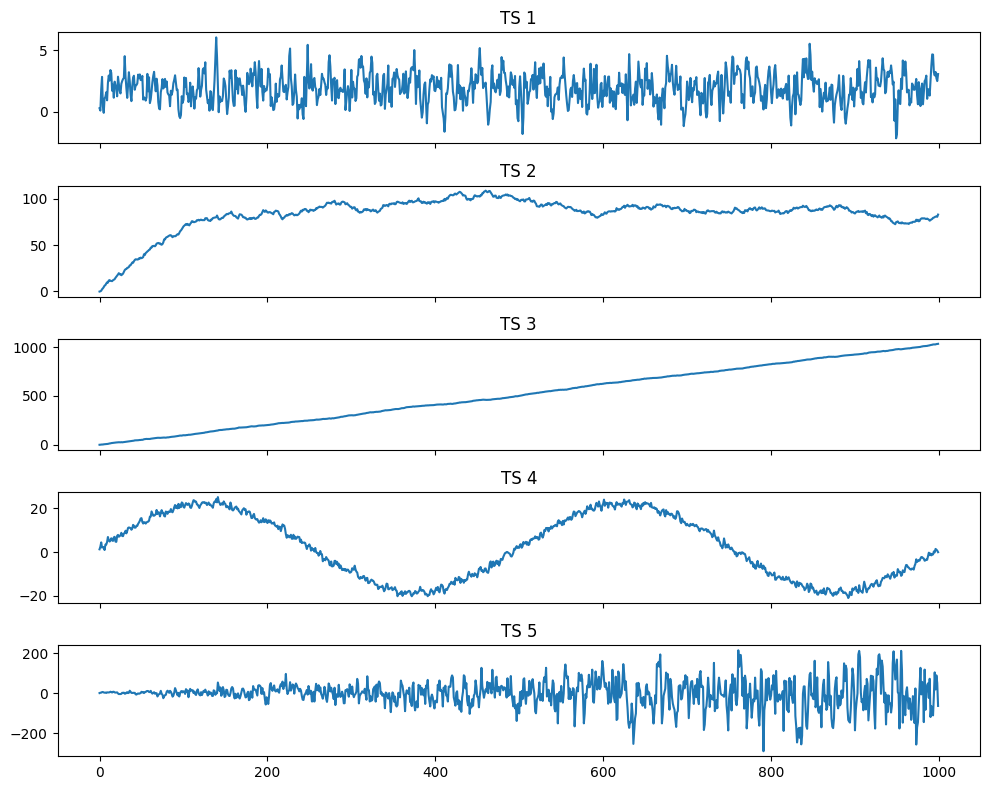

In [ ]:
timeseries = [super_stationary, stationary, nonstationary_trend, nonstationary_seasonality, nonstationary_var]

fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(10, 8), sharex=True)

for i, ts in enumerate(timeseries):
    axs[i].plot(pd.Series(ts), label=f'TS {i+1}')
    axs[i].set_title(f'TS {i+1}')

plt.tight_layout()
plt.show()

### Augmented Dickey-Fuller (ADF) тест

Представьте, что наш временной ряд может быть описан с помощью модели:

$y_t = с + \alpha \cdot y_{t-1} + u_t$,

где $c$ - константа, $u_t$ - случайная ошибка с нулевым средним, постоянной дисперсией и без автокорреляции (= белый шум).

**Если $|\alpha| < 1$**(напр., 0.5), то влияние прошлых значений постепенно уменьшается, временной ряд имеет тенденцию возвращаться к среднему значению. Это похоже на качели — чем дальше они движутся от центра, тем сильнее откат.

Пример: при $\alpha=0.5$ отклонение от среднего в каждый следующий
момент в среднем сокращается в два раза. Это похоже на качели:
после отклонения они возвращаются к центру.

**Если $\alpha = 1$**, то говорят о наличии *unit root* (единичный корень). Модель принимает вид:

$y_t=y_{t-1}+c+u_t$

Если $\alpha$ = 1 (единичный корень есть), каждое новое значение = предыдущее значение + константа $c$ + случайный шок. Если $c \neq 0$, возникает постоянный дрейф. Случайные шоки накапливаются, поэтому ряд может удаляться всё дальше
от начального значения.

Временной ряд может "блуждать" куда угодно. Он как пьяница — каждый шаг в случайном направлении, и мы можем оказаться далеко от того места, откуда начали => **Временной ряд не является стационарным**.

**ADF тест** проверяет наличие *единичного корня*.

H(0): Есть единичный корень. Временной ряд нестационарный.

H(A): Нет единичного корня. Временной ряд стационарный.

**Если нулевую гипотезу можно отвергнуть, то можно сделать вывод, что временной ряд является стационарным.**

Существует два способа отклонить нулевую гипотезу:

С одной стороны, нулевая гипотеза может быть отклонена, если значение p-value ниже установленного уровня значимости. Уровень значимости по умолчанию берут равным 5%.

* <font color='red'>**p-value > уровня значимости (по умолчанию: 0.05)**</font>: Не удается отклонить нулевую гипотезу H(0), есть едичный корень, и временной ряд <font color='red'>не стационарный</font>.
* <font color='green'>**p-value <= уровня значимости (по умолчанию: 0.05)**</font>: Можно отклонить нулевую гипотезу H(0), нет единичного корня, и временной ряд <font color='green'>стационарный</font>.
    
С другой стороны, нулевая гипотеза может быть отвергнута, если тестовая статистика меньше критического значения.
* <font color='red'>**ADF статистика > критического значения**</font>: Не удается отклонить нулевую гипотезу H(0), есть едичный корень, и временной ряд <font color='red'>не стационарный</font>.
* <font color='green'>**ADF статистика <= критического значения**</font>: Можно отклонить нулевую гипотезу H(0), нет единичного корня, и временной ряд <font color='green'>стационарный</font>.

In [ ]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    # обратите внимание на regression="c"
    # - это как раз проверка стационарности вокруг константы
    dftest = adfuller(timeseries, regression="c", autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [ ]:
adf_test(stationary)

Results of Dickey-Fuller Test:
Test Statistic                -6.809082e+00
p-value                        2.139111e-09
#Lags Used                     0.000000e+00
Number of Observations Used    9.990000e+02
Critical Value (1%)           -3.436913e+00
Critical Value (5%)           -2.864437e+00
Critical Value (10%)          -2.568313e+00
dtype: float64


<font color='green'>**p-value <= уровня значимости (по умолчанию: 0.05)**</font> => мы отклоняем нулевую гипотезу, и наш ряд - стационарный!

И еще чуть-чуть про ADF.

ADF называется расширенным тестом Дики-Фуллера, потому что он добавляет лаги первых разностей ряда, чтобы учесть возможную автокорреляцию ошибок.

### Kwiatkowski-Phillips-Schmidt-Shin (KPSS) тест


Представьте, что наш временной ряд может быть описан с помощью модели:

$y_t = c + r_{t} + \varepsilon_t$,

где $c$ - константа, $r_{t} = r_{t-1} + u_{t}$ - *случайное блуждание*,
$\varepsilon_t$ - стационарная случайная ошибка.

Тест KPSS проверяет, меняется ли компонент $r_t$.


H(0): $Var(u_t) = 0$. Временной ряд стационарный, т.к. нет случайного тренда.

H(A): $Var(u_t) > 0$. Временной ряд не стационарный, т.к. присутствует случайный тренд.

**Если нулевую гипотезу отвергнуть нельзя, то можно сделать вывод, что временной ряд является стационарным.**

Нулевая гипотеза не может быть отвергнута, если значение p превышает установленный уровень значимости. Уровень значимости по умолчанию равен 5%.

* <font color='green'>**p-value > уровня значимости (по умолчанию: 0.05)**</font>: Не удается отклонить нулевую гипотезу H(0), и временной ряд <font color='green'>стационарный</font>.
* <font color='red'>**p-value <= уровня значимости (по умолчанию: 0.05)**</font>: Можно отклонить нулевую гипотезу H(0), временной ряд<font color='red'> не стационарный</font>.

С другой стороны, нулевая гипотеза отвергается, если тестовая статистика больше критического значения.
* <font color='red'>**KPSS статистика > критического значения**</font>: Можно отклонить нулевую гипотезу H(0), временной ряд <font color='red'>не стационарный</font>.
* <font color='green'>**KPSS статистика <= критического значения**</font>: Не удается отклонить нулевую гипотезу H(0), и временной ряд <font color='green'>стационарный</font>.

In [ ]:
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    # обратите внимание на regression="c"
    # - это как раз проверка стационарности вокруг константы
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

In [ ]:
kpss_test(stationary)

Results of KPSS Test:
Test Statistic            1.436091
p-value                   0.010000
Lags Used                19.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


/tmp/ipykernel_1212/1069667978.py:5: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




Упс!  <font color='red'>**p-value <= уровня значимости (по умолчанию: 0,05)**</font> => мы отклоняем нулевую гипотезу, и наш ряд - не стационарный!

Мы знаем, что математически ряд является стационарным. Однако KPSS отвергает нулевую гипотезу стационарности. Это пример **ошибки первого рода** - т.е. отвержение верной нулевой гипотезы.

Для сильно автокоррелированных рядов, близких к единичному корню, поведение KPSS действительно может быть нестабильным и зависит в том числе от оценки долгосрочной дисперсии и выбора лагов. [Исследование](https://www.sciencedirect.com/science/article/abs/pii/S030440760400154X?via%3Dihub) на эту тему.

In [ ]:
kpss_test(nonstationary_var)

Results of KPSS Test:
Test Statistic            0.375621
p-value                   0.087664
Lags Used                10.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


Снова проблема!  <font color='green'>**p-value > уровня значимости (по умолчанию: 0,05)**</font> => мы не отклоняем нулевую гипотезу, и наш ряд - стационарный!

Дисперсия ряда изменяется со временем, поэтому ряд не является стационарным. Однако KPSS не отвергает нулевую гипотезу стационарности. Это пример **ошибки второго рода**, т.е. принятие неверной нулевой гипотезы.


**Отдельно про мощность**

Мощность теста — это вероятность отклонить нулевую гипотезу, когда она действительно неверна, т.е. мощность = 1 - вероятность ошибки второго рода.

Важно учитывать, что KPSS предназначен прежде всего для обнаружения нестационарности, связанной со стохастическим трендом. Он не является универсальным тестом всех возможных нарушений стационарности и может, например, не обнаружить изменение дисперсии.
Мощность теста зависит от длины выборки, характера нестационарности и способа оценки долгосрочной дисперсии. Поэтому невозможность отвергнуть \(H_0\) не доказывает стационарность ряда.

**На практике тесты ADF и KPSS часто используются одновременно**:

ADF: H(0) - временной ряд не стационарный

KPSS: H(0) - временной ряд стационарный

Возможные результаты:

* ADF отклоняет H0, KPSS не отклоняет H0 → временной ряд определенно стационарный
* ADF не отклоняет H0, KPSS отклоняет H0 → временной ряд определенно не стационарный
* Оба теста отклоняют H0 или оба теста не отклоняют H0 → однозначного вывода нет

**Если тесты не могут прийти к согласию**, нужно посмотреть на график ряда, проверить наличие тренда, сезонности, выбросов и структурных изменений.

После обоснованного преобразования ряда тесты запускаются повторно.

**ВАЖНО:** каждый тест проверяет ограниченный вид нестационарности.

- ADF ищет единичный корень. Отсутствие единичного корня не исключает изменяющуюся дисперсию, структурный сдвиг и другие нарушения стационарности.
- KPSS в основном ориентирован на наличие стохастического тренда и тоже не выявляет все возможные нарушения.

## Автокорреляция

Следующим важным понятием является автокорреляция. На самом деле это очень простое понятие, которое показывает временную корреляцию между значениями. Оно рассчитывается как нормализованная автоковариация:
$$autocorr_{k} = \frac{cov(y_t, y_{t-k})}{var(y_t)}$$  



In [ ]:
def variance_for_acf(y):
    return auto_covariance(y, lag=0)

In [ ]:
def auto_correlation(y, lag=1):
    return auto_covariance(y, lag) / variance_for_acf(y)

In [ ]:
lag1_autocorr = auto_correlation(humidity_lv['Las Vegas'], lag=1)  # автокорреляция с лагом
print(lag1_autocorr)

lag2_autocorr = auto_correlation(humidity_lv['Las Vegas'], lag=2)
print(lag2_autocorr)

lag7_autocorr = auto_correlation(humidity_lv['Las Vegas'], lag=7)
print(lag7_autocorr)

lag365_autocorr = auto_correlation(humidity_lv['Las Vegas'], lag=365)
print(lag365_autocorr)

0.9503577323523223
0.915589530086783
0.6715935361107849
0.3071988388581009


*Автокорреляция* - ключевая характеристика временных рядов, показывающая, насколько ряд зависит от своих прошлых значений. Почему это важно? Потому что это помогает понять природу временных рядов:

* Если автокорреляция быстро исчезает, ряд напоминает белый шум (независимые наблюдения).
* Если он медленно затухает, ряд может быть нестационарным (например, случайное блуждание).
* Если он периодический, ряд может содержать сезонность.

### Ljung-Box тест

Для проверки автокорреляций на разных лагах обычно используется тест Ljung-Box.

Суть теста Ljung-Box заключается в проверке гипотезы о том, что автокорреляции в ряду до лага $m$ равны нулю. Другими словами, он проверяет, является ли ряд "белым шумом" или содержит значимые автокорреляции.

Статистика *теста Ljung-Box* рассчитывается по формуле:

$Q = n (n + 2) \sum \frac{\rho^2(k)}{n - k}$,

где $n$ - размер выборки, $\rho(k)$ - автокорреляция на лаге $k$ ($k$ от 1 до $m$).

**Тест Ljung-Box** проверяет наличие автокорреляций для первых $m$ лагов.

H(0): Первые $m$ автокорреляции равны 0 (ряд не имеет автокорреляции).

H(A): По крайней мере, одна из первых автокорреляций $m$ не равна 0.

**Если нулевая гипотеза может быть отвергнута, мы можем заключить, что временной ряд автокоррелирован.**

Нулевая гипотеза не может быть отвергнута, если значение p превышает установленный уровень значимости. Уровень значимости по умолчанию равен 5%

* **p-значение > уровня значимости (по умолчанию: 0.05)**: Не удается отклонить нулевую гипотезу H(0), временной ряд **не автокоррелирован**.
* **p-значение <= уровня значимости (по умолчанию: 0.05)**: Отклоняем нулевую гипотезу H(0), временной ряд **автокоррелирован**.

In [ ]:
acorr_ljungbox(humidity_lv['Las Vegas'], return_df=True, lags=14)

,lb_stat,lb_pvalue
1,40873.402789,0.0
2,78811.697251,0.0
3,113323.048451,0.0
4,144177.354685,0.0
5,171311.493279,0.0
6,194892.844969,0.0
7,215307.270982,0.0
8,233048.219118,0.0
9,248578.135924,0.0
10,262568.805537,0.0


🦋 **Рассчитайте ADF, KPSS, тест Ljung-Box с использованием того же подхода для Лос-Анджелеса и сделайте предположения о стационарности и автокорреляции**

In [ ]:
humidity_la = humidity["Los Angeles"]
humidity_la.head()

In [ ]:
humidity_la = humidity_la.resample('D').mean()

In [ ]:
fig = px.line(humidity_la, x=humidity_la.index, y=humidity_la,
              title="Humidity in Los Angeles over time (avg daily frequency)")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

In [ ]:
humidity_la = pd.DataFrame(humidity_la)

In [ ]:
adf_test(humidity_la) # стационарный

In [ ]:
kpss_test(humidity_la) # не стационарный

In [ ]:
acorr_ljungbox(humidity_la, return_df=True, lags=100) # автокоррелирован

## Выводы

Автокорреляция и стационарность имеют решающее значение для анализа временных рядов, поскольку:

* Автокорреляция помогает выявлять закономерности и зависимости между текущими и прошлыми значениями. Она выявляет тенденции, циклы и сезонность, что позволяет лучше прогнозировать и подгонять модель.

* Стационарность гарантирует верность предположений модели. Если ряд является стационарным, его статистические свойства (среднее значение, дисперсия) не меняются со временем, что упрощает анализ и делает модели, подобные ARIMA, более эффективными для прогнозирования.

Без этого прогнозы могут быть ненадежными, а модели могут давать неточные результаты

# SUM UP

* Обсудили природу временных рядов
* Поработали с различными форматами дат в python
* Поработали с resampling и оконными функциями
* Создали визуализации с помощью matplotlib и plotly.express
* Рассчитали простые статистики: среднее, максимум, минимум, дисперсия, ковариация и лаги
* Обсудили стационарность и тесты на стационарность: ADF, KPSS
* Обсудили автокорреляцию и тест на автокорреляцию: Ljung-Box

Пожалуйста, оставьте свой отзыв [здесь](https://forms.gle/2PkHaGn5qN3a5pRj9), давайте сделаем наши уроки лучше :)